In [10]:
import numpy as np, pandas as pd, os, time, random, zipfile, urllib.request
from sklearn.model_selection import train_test_split

WORK = "/content" if os.path.exists("/content") else "/kaggle/working"
URL = ("https://raw.githubusercontent.com/WebClub-NITK/Intelligence-SIG-Recs-2026/main/"
       "mandatory-tasks/recommender-systems-cf-to-dlrm/datasets/dataset%20(tasks%202%20and%203).zip")
os.makedirs(f"{WORK}/data", exist_ok=True); os.makedirs(f"{WORK}/results", exist_ok=True)
urllib.request.urlretrieve(URL, f"{WORK}/data/ctr.zip")
zipfile.ZipFile(f"{WORK}/data/ctr.zip").extractall(f"{WORK}/data")
train_full = pd.read_csv(f"{WORK}/data/train.csv"); test = pd.read_csv(f"{WORK}/data/test.csv")
NUM = [f"integer_feature_{i}" for i in range(1, 14)]
CAT = [f"categorical_feature_{i}" for i in range(1, 27)]

print("rows:", train_full.shape, test.shape, "| click rate train / test:", round(train_full.label.mean(), 4), round(test.label.mean(), 4))
print("most-missing columns:", train_full[NUM + CAT].isna().mean().sort_values(ascending=False).head(3).round(3).to_dict())
card = train_full[CAT].nunique().sort_values()
print("cardinality min / median / max:", card.min(), int(card.median()), card.max(), "| columns above 1000 levels:", int((card > 1000).sum()))

SEED = 42
random.seed(SEED); np.random.seed(SEED)
tr, va = train_test_split(train_full, test_size=0.2, stratify=train_full.label, random_state=SEED)
tr, va = tr.reset_index(drop=True), va.reset_index(drop=True)
med = tr[NUM].median()
def prep_num(d): return np.log1p(d[NUM].fillna(med).clip(lower=0))
_x = prep_num(tr); mu, sd = _x.mean(), _x.std().replace(0, 1)
Xn = {k: ((prep_num(d) - mu) / sd).to_numpy(np.float32) for k, d in [("tr", tr), ("va", va), ("te", test)]}
MIN_COUNT = 5
vocab = {}
for c in CAT:
    vc = tr[c].value_counts()
    vocab[c] = {v: i + 2 for i, v in enumerate(vc[vc >= MIN_COUNT].index)}
rare = {c: set(tr[c].dropna().unique()) - set(vocab[c]) for c in CAT}
def prep_cat(d):
    out = np.zeros((len(d), len(CAT)), dtype=np.int64)
    for j, c in enumerate(CAT):
        col = d[c]; idx = col.map(vocab[c])
        out[:, j] = np.where(idx.notna(), idx.fillna(0), np.where(col.isin(rare[c]), 1, 0))
    return out
Xc = {k: prep_cat(d) for k, d in [("tr", tr), ("va", va), ("te", test)]}
y = {"tr": tr.label.to_numpy(np.float32), "va": va.label.to_numpy(np.float32), "te": test.label.to_numpy(np.float32)}
sizes = [len(vocab[c]) + 2 for c in CAT]

print("split fingerprint | train clicks", int(y["tr"].sum()), "| val clicks", int(y["va"].sum()),
      "| dense sum", round(float(Xn["tr"].sum()), 1), "| cat index sum", int(Xc["tr"].sum()),
      "| val cat index sum", int(Xc["va"].sum()))
assert (int(y["tr"].sum()), int(y["va"].sum()), int(Xc["tr"].sum()), int(Xc["va"].sum())) == (1024, 256, 38103084, 9050373), \
    "split differs from Task 02"
print("OK: identical split and encoding to Task 02 | embedding rows total", sum(sizes))

rows: (40000, 40) (10000, 40) | click rate train / test: 0.032 0.0335
most-missing columns: {'integer_feature_4': 0.4, 'integer_feature_5': 0.385, 'integer_feature_11': 0.385}
cardinality min / median / max: 3 2568 13508 | columns above 1000 levels: 15
split fingerprint | train clicks 1024 | val clicks 256 | dense sum -0.0 | cat index sum 38103084 | val cat index sum 9050373
OK: identical split and encoding to Task 02 | embedding rows total 9912


## Data and split (identical to Task 02)

The same supplied CTR files, the same stratified 80/20 split of `train.csv`
(seed 42) and the same preprocessing, with every statistic learned from the
training part only (median fill, clipping negatives, log1p and standardising
for the 13 dense features; indices for the 26 categorical fields, with 0 for
missing or unseen and 1 for values seen fewer than 5 times). The cell asserts
that the fingerprint equals Task 02's (1,024 and 256 clicks; categorical index
sums 38,103,084 and 9,050,373), so the comparison is on the same data. The
exploration (class balance, missing values, cardinalities, unseen categories)
is in the Task 02 notebook; click rate 3.2% and 15 columns above 1,000 levels
are reproduced here.

In [11]:
import torch, torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, average_precision_score, log_loss, accuracy_score,
                             f1_score, precision_score, recall_score)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

def clipp(p): return np.clip(p, 1e-7, 1 - 1e-7)
def metrics(yt, p, thr):
    pred = (p >= thr).astype(int)
    return dict(roc_auc=roc_auc_score(yt, p), pr_auc=average_precision_score(yt, p), logloss=log_loss(yt, clipp(p)),
                acc=accuracy_score(yt, pred), f1=f1_score(yt, pred, zero_division=0),
                precision=precision_score(yt, pred, zero_division=0), recall=recall_score(yt, pred, zero_division=0))
def best_f1_threshold(yt, p):
    ts = np.linspace(0.01, 0.5, 99)
    return float(ts[int(np.argmax([f1_score(yt, (p >= t).astype(int), zero_division=0) for t in ts]))])

T = {k: (torch.tensor(Xn[k]), torch.tensor(Xc[k]), torch.tensor(y[k])) for k in ["tr", "va"]}   
def predict_proba(m, xd, xc, bs=4096):
    m.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(xd), bs):
            out.append(torch.sigmoid(m(xd[i:i + bs].to(device), xc[i:i + bs].to(device))).cpu().numpy())
    return np.concatenate(out)

def run_model(make, seed=SEED, epochs=15, bs=512, lr=1e-3, wd=1e-5, patience=3, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    m = make().to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
    lossf = nn.BCEWithLogitsLoss()
    xd, xc, yt = [t.to(device) for t in T["tr"]]
    hist, best, bad = [], {"pr": -1.0, "state": None, "ep": 0}, 0
    for ep in range(1, epochs + 1):
        m.train(); perm = torch.randperm(len(yt), device=device); tot = 0.0
        for i in range(0, len(perm), bs):
            idx = perm[i:i + bs]
            opt.zero_grad(set_to_none=True)
            loss = lossf(m(xd[idx], xc[idx]), yt[idx])
            loss.backward(); opt.step(); tot += loss.item() * len(idx)
        p = predict_proba(m, *T["va"][:2])
        row = (ep, tot / len(yt), log_loss(y["va"], clipp(p)), roc_auc_score(y["va"], p), average_precision_score(y["va"], p))
        hist.append(row)
        if verbose: print("epoch %d | train loss %.4f | val loss %.4f | val AUC %.4f | val PR-AUC %.4f" % row)
        if row[4] > best["pr"]:
            best = {"pr": row[4], "ep": ep, "state": {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}}; bad = 0
        else:
            bad += 1
            if bad >= patience: break
    m.load_state_dict(best["state"])
    return m, hist, best

class DLRM(nn.Module):
    def __init__(self, sizes, n_dense, d=8, bottom=(32,), top=(128, 64), interaction="dot"):
        super().__init__()
        self.interaction = interaction
        self.embs = nn.ModuleList([nn.Embedding(s, d) for s in sizes])
        for e in self.embs: nn.init.normal_(e.weight, std=1.0 / d ** 0.5)
        layers, k = [], n_dense
        for h in list(bottom) + [d]:                       
            layers += [nn.Linear(k, h), nn.ReLU()]; k = h
        self.bottom = nn.Sequential(*layers)
        n_vec = len(sizes) + 1                             
        i, j = torch.tril_indices(n_vec, n_vec, offset=-1)  
        self.register_buffer("li", i); self.register_buffer("lj", j)
        k = d + (len(i) if interaction == "dot" else d * len(sizes))
        layers = []
        for h in top:
            layers += [nn.Linear(k, h), nn.ReLU()]; k = h
        layers.append(nn.Linear(k, 1))
        self.top = nn.Sequential(*layers)
    def forward(self, xd, xc):
        x = self.bottom(xd)                                              
        e = [emb(xc[:, j]) for j, emb in enumerate(self.embs)]         
        if self.interaction == "dot":
            Tm = torch.stack([x] + e, dim=1)                             
            z = torch.bmm(Tm, Tm.transpose(1, 2))[:, self.li, self.lj]   
            h = torch.cat([x, z], dim=1)
        else:                                                            
            h = torch.cat([x] + e, dim=1)
        return self.top(h).squeeze(1)


torch.manual_seed(SEED)
dl = DLRM(sizes, len(NUM), d=8)
xd, xc = T["tr"][0][:4], T["tr"][1][:4]
print("logits shape:", tuple(dl(xd, xc).shape))
with torch.no_grad():
    x = dl.bottom(xd); Tm = torch.stack([x] + [emb(xc[:, j]) for j, emb in enumerate(dl.embs)], dim=1)
    manual = torch.stack([(Tm[0, i] * Tm[0, j]).sum() for i in range(Tm.shape[1]) for j in range(i)])
    z0 = torch.bmm(Tm, Tm.transpose(1, 2))[0, dl.li, dl.lj]
print("interaction matches manual dot products:", bool(torch.allclose(manual, z0, atol=1e-5)), "| pairs:", len(dl.li))
n_p = sum(p.numel() for p in dl.parameters())
print("parameters (d=8):", n_p, "| expected 134409 | weight memory MB:", round(n_p * 4 / 1e6, 3))

device: cpu
logits shape: (4,)
interaction matches manual dot products: True | pairs: 351
parameters (d=8): 134409 | expected 134409 | weight memory MB: 0.538


## DLRM implementation (from scratch)

Following Naumov et al. (2019): a bottom MLP maps the 13 dense features to a
vector of length d, equal to the embedding length; each of the 26 categorical
fields has an embedding table of length d; the interaction layer takes the dot
product of every distinct pair among these 27 vectors (27 x 26 / 2 = 351),
concatenates them with the dense vector, and a top MLP outputs the click
logit. Checks: the batched interaction matches a plain loop over pairs, and
the parameter count matches a hand calculation (d = 8: embeddings 79,296,
bottom MLP 712, top MLP 54,401, total 134,409; 0.538 MB in float32).
Differences from Task 02 that are part of the comparison: the explicit
interactions, a bottom MLP for the dense features, and an embedding
initialisation with standard deviation 1/sqrt(d) (Task 02 used PyTorch's
default, N(0, 1)). The training loop, optimiser, batch size and early
stopping are identical to Task 02.

epoch 1 | train loss 0.2653 | val loss 0.1488 | val AUC 0.5855 | val PR-AUC 0.0424
epoch 2 | train loss 0.1388 | val loss 0.1378 | val AUC 0.6577 | val PR-AUC 0.0616
epoch 3 | train loss 0.1299 | val loss 0.1371 | val AUC 0.6756 | val PR-AUC 0.0630
epoch 4 | train loss 0.1237 | val loss 0.1393 | val AUC 0.6636 | val PR-AUC 0.0624
epoch 5 | train loss 0.1171 | val loss 0.1447 | val AUC 0.6585 | val PR-AUC 0.0596
epoch 6 | train loss 0.1091 | val loss 0.1475 | val AUC 0.6469 | val PR-AUC 0.0564
DLRM d=8 | best epoch 3 | params 134409 | weight MB 0.538 | train time (s) 6
val F1 threshold: 0.06 {'roc_auc': 0.6756, 'pr_auc': 0.063, 'logloss': 0.1371, 'acc': 0.8389, 'f1': 0.1092, 'precision': 0.0663, 'recall': 0.3086}
Task 02 refs (val, seed 42, Colab CPU): baseline A PR-AUC 0.1049 AUC 0.7366 logloss 0.1300 | selected F PR-AUC 0.1014 AUC 0.7204 logloss 0.1315
references: random PR-AUC about 0.032 | constant-rate log loss about 0.1416


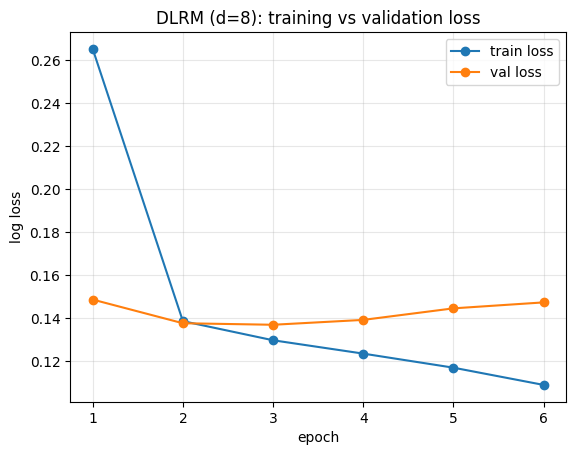

In [12]:
t0 = time.time()
m_dl, hist_dl, best_dl = run_model(lambda: DLRM(sizes, len(NUM), d=8), seed=SEED)
train_dl = time.time() - t0
p_dl = predict_proba(m_dl, *T["va"][:2])
thr_dl = best_f1_threshold(y["va"], p_dl)
mv = metrics(y["va"], p_dl, thr_dl)
n_dl = sum(p.numel() for p in m_dl.parameters())
print("DLRM d=8 | best epoch", best_dl["ep"], "| params", n_dl, "| weight MB", round(n_dl * 4 / 1e6, 3), "| train time (s)", round(train_dl))
print("val F1 threshold:", round(thr_dl, 3), {k: round(float(v), 4) for k, v in mv.items()})
print("Task 02 refs (val, seed 42, Colab CPU): baseline A PR-AUC 0.1049 AUC 0.7366 logloss 0.1300 | selected F PR-AUC 0.1014 AUC 0.7204 logloss 0.1315")
print("references: random PR-AUC about", round(float(y["va"].mean()), 4), "| constant-rate log loss about 0.1416")

h = np.array(hist_dl)
plt.plot(h[:, 0], h[:, 1], marker="o", label="train loss"); plt.plot(h[:, 0], h[:, 2], marker="o", label="val loss")
plt.xlabel("epoch"); plt.ylabel("log loss"); plt.legend(); plt.grid(alpha=0.3); plt.title("DLRM (d=8): training vs validation loss")
plt.savefig(f"{WORK}/results/dlrm_first_curves.png", dpi=150, bbox_inches="tight"); plt.show()

## First DLRM run (d = 8, seed 42)

| Epoch | Train loss | Val loss | Val AUC | Val PR-AUC |
|---|---|---|---|---|
| 1 | 0.2653 | 0.1488 | 0.5855 | 0.0424 |
| 2 | 0.1388 | 0.1378 | 0.6577 | 0.0616 |
| 3 | 0.1299 | 0.1371 | 0.6756 | 0.0630 |
| 4 | 0.1237 | 0.1393 | 0.6636 | 0.0624 |
| 5 | 0.1171 | 0.1447 | 0.6585 | 0.0596 |
| 6 | 0.1091 | 0.1475 | 0.6469 | 0.0564 |

Best epoch 3: ROC-AUC 0.6756, PR-AUC 0.0630 (2.0 times the click rate), log
loss 0.1371, F1 0.1092 (precision 0.0663, recall 0.3086, accuracy 0.8389,
below the 0.968 of a model that never predicts a click). 134,409 parameters,
6 seconds. On the same seed and hardware, Task 02's baseline reached PR-AUC
0.1049 and its selected model 0.1014, so this DLRM is clearly weaker, and it
overfits quickly: by epochs 5 and 6 the validation log loss is above the
constant-rate predictor's 0.1416.

In [13]:
class DLRM(nn.Module):
    def __init__(self, sizes, n_dense, d=8, bottom=(32,), top=(128, 64), interaction="dot", dropout=0.0, emb_std=None):
        super().__init__()
        self.interaction = interaction
        self.embs = nn.ModuleList([nn.Embedding(s, d) for s in sizes])
        std = 1.0 / d ** 0.5 if emb_std is None else emb_std
        for e in self.embs: nn.init.normal_(e.weight, std=std)
        layers, k = [], n_dense
        for h in list(bottom) + [d]:
            layers += [nn.Linear(k, h), nn.ReLU()]; k = h
        self.bottom = nn.Sequential(*layers)
        n_vec = len(sizes) + 1
        i, j = torch.tril_indices(n_vec, n_vec, offset=-1)
        self.register_buffer("li", i); self.register_buffer("lj", j)
        k = d + (len(i) if interaction == "dot" else d * len(sizes))
        layers = []
        for h in top:
            layers += [nn.Linear(k, h), nn.ReLU(), nn.Dropout(dropout)]; k = h
        layers.append(nn.Linear(k, 1))
        self.top = nn.Sequential(*layers)
    def forward(self, xd, xc):
        x = self.bottom(xd)
        e = [emb(xc[:, j]) for j, emb in enumerate(self.embs)]
        if self.interaction == "dot":
            Tm = torch.stack([x] + e, dim=1)
            z = torch.bmm(Tm, Tm.transpose(1, 2))[:, self.li, self.lj]
            h = torch.cat([x, z], dim=1)
        else:
            h = torch.cat([x] + e, dim=1)
        return self.top(h).squeeze(1)

torch.manual_seed(SEED)
print("check, d=8 default params:", sum(p.numel() for p in DLRM(sizes, len(NUM), d=8).parameters()), "(expect 134409)")


check, d=8 default params: 134409 (expect 134409)


In [14]:
cfgs = {
 "D1  dot d8 top(128,64) dr0.0 [first run]": dict(d=8,  top=(128, 64), dropout=0.0, interaction="dot"),
 "D1n same, embedding init N(0,1)":          dict(d=8,  top=(128, 64), dropout=0.0, interaction="dot", emb_std=1.0),
 "P1  dot d4 top(32) dr0.0":                 dict(d=4,  top=(32,),     dropout=0.0, interaction="dot"),
 "P1c concat d4 top(32) dr0.0":              dict(d=4,  top=(32,),     dropout=0.0, interaction="concat"),
 "P2  dot d8 top(64) dr0.3":                 dict(d=8,  top=(64,),     dropout=0.3, interaction="dot"),
 "P2c concat d8 top(64) dr0.3":              dict(d=8,  top=(64,),     dropout=0.3, interaction="concat"),
 "D4  dot d4 top(64) dr0.3":                 dict(d=4,  top=(64,),     dropout=0.3, interaction="dot"),
 "D5  dot d16 top(64) dr0.3":                dict(d=16, top=(64,),     dropout=0.3, interaction="dot")}

res, t_all = {}, time.time()
for name, cfg in cfgs.items():
    res[name] = []
    for s_ in (42, 43, 44):
        t0 = time.time()
        m_, h_, b_ = run_model(lambda: DLRM(sizes, len(NUM), **cfg), seed=s_, verbose=False)
        e = h_[b_["ep"] - 1]
        res[name].append((b_["ep"], e[2], e[3], e[4], sum(p.numel() for p in m_.parameters()), time.time() - t0))
rows = []
for n, rs in res.items():
    a = np.array(rs, dtype=float)
    rows.append((n, cfgs[n]["interaction"], int(a[0, 4]), a[:, 0].mean(), a[:, 3].mean(), a[:, 3].std(), a[:, 2].mean(), a[:, 2].std(), a[:, 1].mean(), a[:, 5].mean()))
sw3 = pd.DataFrame(rows, columns=["config", "interaction", "params", "best epoch", "PR-AUC", "PR std", "AUC", "AUC std", "logloss", "sec/run"])
print(sw3.round(4).to_string(index=False)); print("sweep time (s):", round(time.time() - t_all))

dot = sw3[sw3["interaction"] == "dot"]
top = dot.loc[dot["PR-AUC"].idxmax()]
chosen3 = dot[dot["PR-AUC"] >= top["PR-AUC"] - top["PR std"]].sort_values("params").iloc[0]["config"]
print("selected DLRM by the rule:", chosen3)
print("Task 02 refs (3-seed means): A PR-AUC 0.0994 (0.0042) 169,153 params | selected F PR-AUC 0.1036 (0.0075) 43,457 params")

                                  config interaction  params  best epoch  PR-AUC  PR std    AUC  AUC std  logloss  sec/run
D1  dot d8 top(128,64) dr0.0 [first run]         dot  134409      3.6667  0.0735  0.0083 0.6919   0.0179   0.1357   6.1987
         D1n same, embedding init N(0,1)         dot  134409      4.0000  0.0687  0.0084 0.6592   0.0169   0.1412   6.6178
                P1  dot d4 top(32) dr0.0         dot   51653      8.0000  0.0698  0.0040 0.6878   0.0059   0.1374   8.6333
             P1c concat d4 top(32) dr0.0      concat   43749     10.0000  0.0892  0.0056 0.7231   0.0071   0.1315   6.4348
                P2  dot d8 top(64) dr0.3         dot  103113      5.6667  0.0780  0.0063 0.6949   0.0172   0.1357   7.6850
             P2c concat d8 top(64) dr0.3      concat   93961      6.3333  0.0921  0.0026 0.7331   0.0084   0.1307   5.6414
                D4  dot d4 top(64) dr0.3         dot   63077      6.6667  0.0738  0.0072 0.6982   0.0043   0.1364   8.3664
               D

In [15]:
print("Ablation: effect of the interaction layer at matched settings (val PR-AUC, seeds 42, 43, 44)")
for a_, b_ in [("P1  dot d4 top(32) dr0.0", "P1c concat d4 top(32) dr0.0"), ("P2  dot d8 top(64) dr0.3", "P2c concat d8 top(64) dr0.3")]:
    pa = [r[3] for r in res[a_]]; pb = [r[3] for r in res[b_]]
    diff = [x - z for x, z in zip(pa, pb)]
    print(a_.split()[0], "dot", np.round(pa, 4), "| concat", np.round(pb, 4), "| per-seed difference", np.round(diff, 4),
          "| mean", round(float(np.mean(diff)), 4))
pa = [r[3] for r in res["D1  dot d8 top(128,64) dr0.0 [first run]"]]; pb = [r[3] for r in res["D1n same, embedding init N(0,1)"]]
print("Init check (D1 vs D1n), PR-AUC per seed:", np.round(pa, 4), "vs", np.round(pb, 4))

Ablation: effect of the interaction layer at matched settings (val PR-AUC, seeds 42, 43, 44)
P1 dot [0.0722 0.0641 0.0731] | concat [0.0812 0.0929 0.0933] | per-seed difference [-0.009  -0.0288 -0.0202] | mean -0.0193
P2 dot [0.0692 0.0839 0.0809] | concat [0.0898 0.0957 0.0909] | per-seed difference [-0.0206 -0.0118 -0.01  ] | mean -0.0141
Init check (D1 vs D1n), PR-AUC per seed: [0.063  0.0832 0.0743] vs [0.0569 0.0757 0.0735]


epoch 1 | train loss 0.2865 | val loss 0.1476 | val AUC 0.5713 | val PR-AUC 0.0377
epoch 2 | train loss 0.1424 | val loss 0.1375 | val AUC 0.6688 | val PR-AUC 0.0617
epoch 3 | train loss 0.1350 | val loss 0.1346 | val AUC 0.6963 | val PR-AUC 0.0737
epoch 4 | train loss 0.1279 | val loss 0.1335 | val AUC 0.7084 | val PR-AUC 0.0811
epoch 5 | train loss 0.1209 | val loss 0.1338 | val AUC 0.7124 | val PR-AUC 0.0831
epoch 6 | train loss 0.1124 | val loss 0.1368 | val AUC 0.7012 | val PR-AUC 0.0787
epoch 7 | train loss 0.1021 | val loss 0.1419 | val AUC 0.6932 | val PR-AUC 0.0789
epoch 8 | train loss 0.0915 | val loss 0.1499 | val AUC 0.6826 | val PR-AUC 0.0747
selected: D5  dot d16 top(64) dr0.3 | best epoch 5 | params 183185 | weight MB 0.733 | train time (s) 8
val F1 threshold: 0.09 {'roc_auc': 0.7124, 'pr_auc': 0.0831, 'logloss': 0.1338, 'acc': 0.9066, 'f1': 0.1463, 'precision': 0.1034, 'recall': 0.25}
Task 02 selected F (seed 42, val): PR-AUC 0.1014 AUC 0.7204 logloss 0.1315 F1 0.1616 |

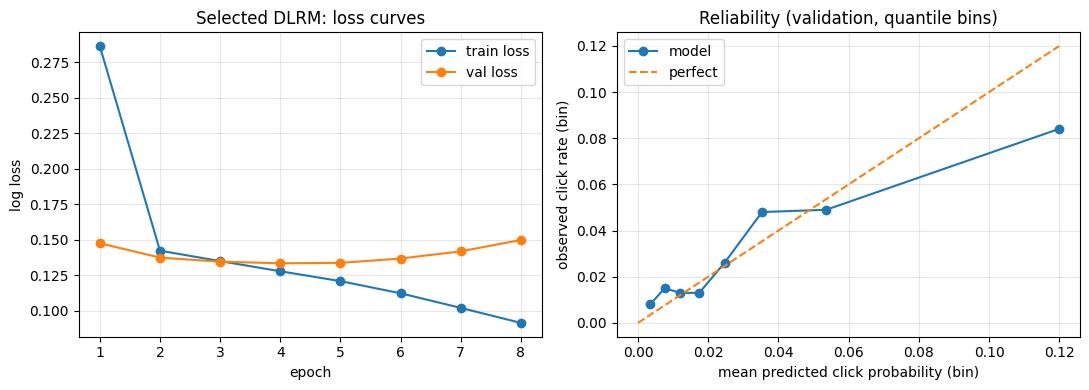

In [16]:
from sklearn.calibration import calibration_curve
cfg_sel = cfgs[chosen3]
t0 = time.time()
m_f, hist_f, best_f = run_model(lambda: DLRM(sizes, len(NUM), **cfg_sel), seed=SEED, verbose=True)
train_s = time.time() - t0
p_va = predict_proba(m_f, *T["va"][:2])
thr_f = best_f1_threshold(y["va"], p_va)
val_m = metrics(y["va"], p_va, thr_f)
n_params = sum(p.numel() for p in m_f.parameters())
print("selected:", chosen3, "| best epoch", best_f["ep"], "| params", n_params,
      "| weight MB", round(n_params * 4 / 1e6, 3), "| train time (s)", round(train_s))
print("val F1 threshold:", round(thr_f, 3), {k: round(float(v), 4) for k, v in val_m.items()})
print("Task 02 selected F (seed 42, val): PR-AUC 0.1014 AUC 0.7204 logloss 0.1315 F1 0.1616 | 43,457 params, 0.17 MB")

frac, mean_p = calibration_curve(y["va"], p_va, n_bins=8, strategy="quantile")
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
h = np.array(hist_f)
ax[0].plot(h[:, 0], h[:, 1], marker="o", label="train loss"); ax[0].plot(h[:, 0], h[:, 2], marker="o", label="val loss")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("log loss"); ax[0].legend(); ax[0].grid(alpha=0.3); ax[0].set_title("Selected DLRM: loss curves")
mx = max(mean_p.max(), frac.max())
ax[1].plot(mean_p, frac, marker="o", label="model"); ax[1].plot([0, mx], [0, mx], "--", label="perfect")
ax[1].set_xlabel("mean predicted click probability (bin)"); ax[1].set_ylabel("observed click rate (bin)")
ax[1].legend(); ax[1].grid(alpha=0.3); ax[1].set_title("Reliability (validation, quantile bins)")
plt.tight_layout(); plt.savefig(f"{WORK}/results/task03_selected.png", dpi=150, bbox_inches="tight"); plt.show()

In [17]:
def boot(yt, p, n=1000, seed=0):
    rng = np.random.default_rng(seed); idx = np.arange(len(yt)); out = []
    for _ in range(n):
        s = rng.choice(idx, len(idx), replace=True)
        if yt[s].sum() == 0: continue
        out.append((roc_auc_score(yt[s], p[s]), average_precision_score(yt[s], p[s]), log_loss(yt[s], clipp(p[s]), labels=[0, 1])))
    a = np.array(out)
    return np.percentile(a, 2.5, axis=0), np.percentile(a, 97.5, axis=0)

Xte = (torch.tensor(Xn["te"]), torch.tensor(Xc["te"]))
p_te = predict_proba(m_f, *Xte)
test_m = metrics(y["te"], p_te, thr_f)
print("TEST (one run, val-chosen threshold %.3f):" % thr_f, {k: round(float(v), 4) for k, v in test_m.items()})
print("Task 02 test (one run): ROC-AUC 0.6676 PR-AUC 0.0647 logloss 0.1441 F1 0.0845 | random PR-AUC about", round(float(y["te"].mean()), 4))
lo_v, hi_v = boot(y["va"], p_va); lo_t, hi_t = boot(y["te"], p_te)
for name, yt, p, lo, hi in [("val", y["va"], p_va, lo_v, hi_v), ("test", y["te"], p_te, lo_t, hi_t)]:
    print(name, "| ROC-AUC %.3f [%.3f, %.3f] | PR-AUC %.4f [%.4f, %.4f] | log loss %.4f [%.4f, %.4f]" % (
        roc_auc_score(yt, p), lo[0], hi[0], average_precision_score(yt, p), lo[1], hi[1], log_loss(yt, clipp(p)), lo[2], hi[2]))
print("mean predicted probability val %.4f | test %.4f | observed val %.4f | test %.4f" % (
    p_va.mean(), p_te.mean(), y["va"].mean(), y["te"].mean()))
print("predicted-positive share at the threshold: val %.4f | test %.4f" % ((p_va >= thr_f).mean(), (p_te >= thr_f).mean()))

TEST (one run, val-chosen threshold 0.090): {'roc_auc': 0.681, 'pr_auc': 0.0665, 'logloss': 0.1427, 'acc': 0.9031, 'f1': 0.1053, 'precision': 0.0762, 'recall': 0.1701}
Task 02 test (one run): ROC-AUC 0.6676 PR-AUC 0.0647 logloss 0.1441 F1 0.0845 | random PR-AUC about 0.0335
val | ROC-AUC 0.712 [0.681, 0.744] | PR-AUC 0.0831 [0.0667, 0.1091] | log loss 0.1338 [0.1216, 0.1463]
test | ROC-AUC 0.681 [0.655, 0.708] | PR-AUC 0.0665 [0.0557, 0.0846] | log loss 0.1427 [0.1306, 0.1556]
mean predicted probability val 0.0342 | test 0.0332 | observed val 0.0320 | test 0.0335
predicted-positive share at the threshold: val 0.0774 | test 0.0748


In [19]:
import sys, sklearn, matplotlib
print("python", sys.version.split()[0], "| numpy", np.__version__, "| pandas", pd.__version__,
      "| torch", torch.__version__, "| scikit-learn", sklearn.__version__, "| matplotlib", matplotlib.__version__)
print("device:", device, "| seeds: split", SEED, "| sweep 42, 43, 44 | selected model", SEED)

L = ["# Task 03 results", "",
     "Selected DLRM: %s | params %d | weight memory %.3f MB | train time %.0f s | best epoch %d | threshold %.3f" % (
         chosen3, n_params, n_params * 4 / 1e6, train_s, best_f["ep"], thr_f), "",
     "## Sweep (mean over seeds 42, 43, 44; validation)", "",
     "| config | interaction | params | best epoch | PR-AUC | PR std | AUC | AUC std | log loss | sec/run |", "|---|---|---|---|---|---|---|---|---|---|"]
for _, r in sw3.iterrows():
    L.append("| %s | %s | %d | %.1f | %.4f | %.4f | %.4f | %.4f | %.4f | %.1f |" % (
        r["config"], r["interaction"], r["params"], r["best epoch"], r["PR-AUC"], r["PR std"], r["AUC"], r["AUC std"], r["logloss"], r["sec/run"]))
L += ["", "## Ablation: dot-product interactions against concatenation (val PR-AUC per seed 42, 43, 44)", "",
      "| pair | dot | concat | difference per seed | mean difference |", "|---|---|---|---|---|"]
for a_, b_ in [("P1  dot d4 top(32) dr0.0", "P1c concat d4 top(32) dr0.0"), ("P2  dot d8 top(64) dr0.3", "P2c concat d8 top(64) dr0.3")]:
    pa = [r[3] for r in res[a_]]; pb = [r[3] for r in res[b_]]; dd = [x - z for x, z in zip(pa, pb)]
    L.append("| %s vs %s | %s | %s | %s | %.4f |" % (a_.split()[0], b_.split()[0], np.round(pa, 4).tolist(), np.round(pb, 4).tolist(), np.round(dd, 4).tolist(), float(np.mean(dd))))
L += ["", "## Selected DLRM, val and test (test: one run)", "",
      "| split | ROC-AUC (95% CI) | PR-AUC (95% CI) | log loss (95% CI) | acc | F1 | precision | recall |", "|---|---|---|---|---|---|---|---|"]
for name, m_, lo, hi in [("val", val_m, lo_v, hi_v), ("test", test_m, lo_t, hi_t)]:
    L.append("| %s | %.3f [%.3f, %.3f] | %.4f [%.4f, %.4f] | %.4f [%.4f, %.4f] | %.4f | %.4f | %.4f | %.4f |" % (
        name, m_["roc_auc"], lo[0], hi[0], m_["pr_auc"], lo[1], hi[1], m_["logloss"], lo[2], hi[2], m_["acc"], m_["f1"], m_["precision"], m_["recall"]))
open(f"{WORK}/results/task03_results.md", "w").write("\n".join(L))



python 3.13.15 | numpy 2.1.3 | pandas 2.3.3 | torch 2.11.0+cpu | scikit-learn 1.6.1 | matplotlib 3.10.0
device: cpu | seeds: split 42 | sweep 42, 43, 44 | selected model 42


2002

In [20]:
print("results folder:", sorted(os.listdir(f"{WORK}/results")))

results folder: ['dlrm_first_curves.png', 'task03_results.md', 'task03_selected.png']
